# Notebook 03 – Time-Series Modeling
IITB Project – Problem ID-9: Effect of Feedback on Affective and Cognitive Measures

## Goals of This Notebook
1. Load trial-level features and participant metadata.
2. Prepare time-series sequences for ML/DL models.
3. Train models to predict affective states per trial:
   - Baseline: Linear Regression / Random Forest  
   - Advanced: LSTM / GRU / Transformer-based models
4. Evaluate model performance using:
   - Mean Absolute Error (MAE)
   - Root Mean Square Error (RMSE)
   - Correlation with actual values
5. Save trained models and evaluation metrics for downstream analysis.

## Input Data
- preprocessed_features.csv → trial-level features  
- Optional: participant metadata for stratification

## Output
- trained_models/ → serialized ML/DL models  
- model_metrics.csv → evaluation metrics per model  
- predicted_vs_actual_plots/ → comparison plots


Using device: cpu
Data loaded. Shape: (1448, 186)
Prepared data. Train: (1158, 183) Test: (290, 183)
Targets: ['engagement', 'confusion']

ML Results:
               Model           MAE          RMSE        R2
0  LinearRegression  4.200871e-14  6.685419e-14  1.000000
1      RandomForest  1.476119e-01  4.621382e-01  0.973994
Epoch 1: Train 0.0455, Val 0.0453
Epoch 2: Train 0.0432, Val 0.0439
Epoch 3: Train 0.0422, Val 0.0453
Epoch 4: Train 0.0416, Val 0.0450
Epoch 5: Train 0.0410, Val 0.0458
Epoch 6: Train 0.0411, Val 0.0455
Epoch 7: Train 0.0402, Val 0.0466
Epoch 8: Train 0.0395, Val 0.0475
Epoch 9: Train 0.0389, Val 0.0489
Epoch 10: Train 0.0389, Val 0.0483
Early stopping.


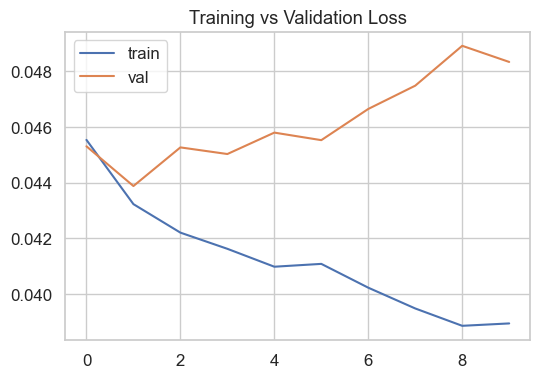


DL Results:
               Model        MAE       RMSE        R2
0  BiLSTM+Attention  11.781562  20.287241 -0.038547
✅ Attention weights saved at: C:\Users\imran\iitb_project\results\attention_weights.npy


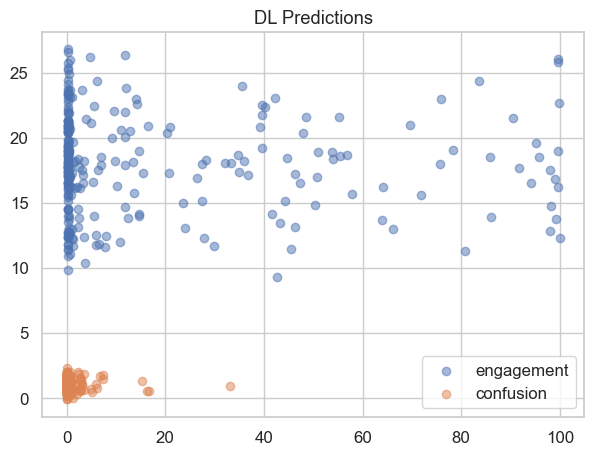

All results saved in: C:\Users\imran\iitb_project\results


In [3]:
# ========================================
# 03_time_series_modeling.ipynb
# Problem ID-9: Effect of Feedback on Affective and Cognitive Measures
# ========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", font_scale=1.1)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ================================
# Config
# ================================
DATA_PATH = Path("../results/preprocessed_features.csv")
RESULTS_PATH = Path("../results")
MODELS_PATH = Path("../models")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print("Using device:", device)

# ================================
# Step 1: Load Data
# ================================
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_preprocessing_time_series.ipynb first.")

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Data loaded. Shape:", df.shape)

# Encode feedback
if "feedback" not in df.columns:
    df["feedback"] = "UNKNOWN"
le = LabelEncoder()
df["feedback_code"] = le.fit_transform(df["feedback"].astype(str))

# Features and targets
exclude = {"participant", "trial_id", "feedback", "feedback_time"}
feature_cols = [c for c in df.columns if c not in exclude]
target_cols = [c for c in ["engagement", "confusion"] if c in df.columns]
if not target_cols:
    raise ValueError("No target columns found.")

X = df[feature_cols].fillna(0).values
y = df[target_cols].fillna(0).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 Scale targets for DL (but keep original for ML)
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print("Prepared data. Train:", X_train.shape, "Test:", X_test.shape)
print("Targets:", target_cols)

# ================================
# Step 2: ML Baselines (regression only)
# ================================
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}, y_pred

ml_results = []

lr = LinearRegression()
metrics_lr, y_pred_lr = evaluate_model(lr, X_train, y_train, X_test, y_test)
ml_results.append({"Model": "LinearRegression", **metrics_lr})

rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)  # 🔹 stronger RF
metrics_rf, y_pred_rf = evaluate_model(rf, X_train, y_train, X_test, y_test)
ml_results.append({"Model": "RandomForest", **metrics_rf})

ml_df = pd.DataFrame(ml_results)
ml_df.to_csv(RESULTS_PATH / "ml_baseline_metrics.csv", index=False)
print("\nML Results:\n", ml_df)

# ================================
# Step 3: Deep Learning (BiLSTM+Attention)
# ================================
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=15):  # 🔹 slightly longer sequence
        self.samples = []
        X = X.astype(np.float32)
        y = y.astype(np.float32)
        for i in range(len(X) - seq_len):
            self.samples.append((X[i:i+seq_len], y[i+seq_len]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        X_seq, y_seq = self.samples[idx]
        return torch.from_numpy(X_seq), torch.from_numpy(y_seq)

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, lstm_out):
        weights = torch.softmax(self.attn(lstm_out).squeeze(-1), dim=1)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)
        return context, weights

class BiLSTMAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=None):  # 🔹 bigger hidden size
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=1,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.attn = Attention(hidden_dim*2)
        out_dim = len(target_cols) if output_dim is None else output_dim
        self.fc = nn.Linear(hidden_dim*2, out_dim)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, weights = self.attn(lstm_out)
        return self.fc(context), weights

SEQ_LEN, BATCH_SIZE, EPOCHS = 15, 32, 60  # 🔹 more epochs
train_ds = SequenceDataset(X_train, y_train_scaled, seq_len=SEQ_LEN)
test_ds  = SequenceDataset(X_test, y_test_scaled, seq_len=SEQ_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

model = BiLSTMAttention(input_dim=X.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)  # 🔹 tuned LR

history = {"train": [], "val": []}
best_val, patience, no_improve = float("inf"), 8, 0

for epoch in range(1, EPOCHS+1):
    model.train()
    total_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds, _ = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train += loss.item() * xb.size(0)
    avg_train = total_train / len(train_loader.dataset)

    model.eval()
    total_val = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds, _ = model(xb)
            total_val += criterion(preds, yb).item() * xb.size(0)
    avg_val = total_val / len(test_loader.dataset)

    history["train"].append(avg_train)
    history["val"].append(avg_val)
    print(f"Epoch {epoch}: Train {avg_train:.4f}, Val {avg_val:.4f}")

    if avg_val < best_val:
        best_val = avg_val
        no_improve = 0
        torch.save(model.state_dict(), MODELS_PATH / "attention_model.pt")
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping.")
            break

plt.figure(figsize=(6,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.legend(); plt.title("Training vs Validation Loss")
plt.savefig(RESULTS_PATH / "dl_training_curve.png", dpi=200)
plt.show()

# ================================
# Evaluation (inverse-transform targets)
# ================================
model.load_state_dict(torch.load(MODELS_PATH / "attention_model.pt", map_location=device))
model.eval()
y_true, y_pred, attn_all = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds, weights = model(xb)
        y_true.append(yb.numpy())
        y_pred.append(preds.numpy())
        attn_all.append(weights.numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
attn_all = np.vstack(attn_all)

# 🔹 Inverse transform predictions to original scale
y_true_orig = y_scaler.inverse_transform(y_true)
y_pred_orig = y_scaler.inverse_transform(y_pred)

mae = mean_absolute_error(y_true_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
r2 = r2_score(y_true_orig, y_pred_orig)

dl_df = pd.DataFrame([{"Model":"BiLSTM+Attention","MAE":float(mae),"RMSE":float(rmse),"R2":float(r2)}])
dl_df.to_csv(RESULTS_PATH / "dl_metrics.csv", index=False)

np.save(RESULTS_PATH / "attention_weights.npy", attn_all)

print("\nDL Results:\n", dl_df)
print("✅ Attention weights saved at:", (RESULTS_PATH / "attention_weights.npy").resolve())

plt.figure(figsize=(7,5))
plt.scatter(y_true_orig[:,0], y_pred_orig[:,0], alpha=0.5, label=target_cols[0])
if y_true_orig.shape[1] > 1:
    plt.scatter(y_true_orig[:,1], y_pred_orig[:,1], alpha=0.5, label=target_cols[1])
plt.legend(); plt.title("DL Predictions")
plt.savefig(RESULTS_PATH / "dl_predictions.png", dpi=200)
plt.show()

print("All results saved in:", RESULTS_PATH.resolve())
